<a href="https://colab.research.google.com/github/shin-jini/BUPA_Case_Study/blob/main/Descriptive_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# SECTION 1:
#Payment data Insights: Descriptive and Diagnostic Analytics

In [2]:
pd.options.display.float_format = '{:.2f}'.format
payments = pd.read_csv('https://raw.githubusercontent.com/shin-jini/BUPA_Case_Study/main/Payement_Information/Payments_Master.csv')
team=pd.read_csv('https://raw.githubusercontent.com/shin-jini/BUPA_Case_Study/main/Payement_Information/Research_team_Master.csv',sep=';')
members=pd.read_csv('https://raw.githubusercontent.com/shin-jini/BUPA_Case_Study/main/Payement_Information/Research_Team_members_Master.csv')
fraud=pd.read_csv('https://raw.githubusercontent.com/shin-jini/BUPA_Case_Study/main/Payement_Information/Fraud_Cases_Master.csv')
print("Payments")
display(payments.head(2))
print("Research team")
display(team.head(2))
print("Team Members")
display(members.head(2))
print("Fraud")
display(fraud.head(2))
payments.isnull().sum().to_frame(name='missing').T

Payments


,Date received,Research team,Submitted by,Date of invoice,Invoice number,Description of spend,Invoice value,Date of authorisation,Authorised by,Payment due date,Date of payment,Payment amount,Payment authoriser,Payment Status,Type of expense,Company,phone_number,email
0,2025-04-27,Genetics,Melinda White,2025-04-14,INV-76915,"""Procured DNA extraction kits for isolating hi...",13319.94,2025-05-11,Kevin Ross,2025-06-09,2025-05-29,13319.94,Antonio Wilson,Paid,Software Licenses,IG Group Holdings,(624)900-2038x3126,uayers@ig.com
1,2025-06-02,Immunology,Daniel Peterson,2025-05-28,INV-64102,"""Purchase of endotoxin-free reagents for in vi...",14696.98,2025-06-14,Sarah Collins,2025-07-06,2025-06-22,14696.98,Antonio Wilson,Paid,Clinical Trial,Workspace Group,3967724119,jose87@workspace.com


Research team


,Research team,Director,Location,Affiliation,Research type,Annual budget,Item type,Item budget,Comments
0,Oncology,Gabriel Sullivan,Zurich,Harvard,Basic Research,21680552.51,Personnel,621512.01,Skin operation part short focus establish assu...
1,Oncology,Kyle Mckay,Munich,ETH Zurich,Basic Research,26683921.43,IT Infrastructure,3320269.70,Raise recently room or.


Team Members


,Team,Location,Name,Role
0,Oncology,Zurich,Christopher Wilson,Manager
1,Oncology,Zurich,Leslie Bradley,Analyst


Fraud


,Date received,Research team,Submitted by,Date of invoice,Invoice number,Description of spend,Invoice value,Date of authorisation,Authorised by,Payment due date,Date of payment,Payment amount,Payment authoriser,Payment Status,Type of expense,Fraud flag,Company,phone_number,email
0,2025-04-21,Immunology,Lauren Houston,2025-04-18,INV-02278,"""Procured immunohistochemistry staining kits f...",19366.92,2025-04-26,Sarah Collins,2025-06-05,2025-05-05,19366.92,Antonio Wilson,Paid,Lab Supplies,1,Quilter,(584)219-2504x7930,brandonramirez@quilter.com
1,2025-01-20,Neurology,Carlos Martin,2025-01-19,INV-78486,"""Subscription to specialized neuroscience data...",6839.49,2025-02-04,Dennis White,2025-03-06,2025-02-08,6839.49,Antonio Wilson,Paid,Travel,1,Volution Group,744.798.1953x276,lopezjennifer@volution.com


,Date received,Research team,Submitted by,Date of invoice,Invoice number,Description of spend,Invoice value,Date of authorisation,Authorised by,Payment due date,Date of payment,Payment amount,Payment authoriser,Payment Status,Type of expense,Company,phone_number,email
missing,0,0,0,0,0,0,0,0,0,0,572,572,0,0,0,0,0,0


In [3]:
in_num=set(payments['Invoice number']).intersection(set(fraud['Invoice number']))
combined_df = pd.concat([payments, fraud], ignore_index=True)
combined_df=combined_df[~combined_df['Invoice number'].isin(in_num)]
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2956 entries, 0 to 2999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date received          2956 non-null   object 
 1   Research team          2956 non-null   object 
 2   Submitted by           2956 non-null   object 
 3   Date of invoice        2956 non-null   object 
 4   Invoice number         2956 non-null   object 
 5   Description of spend   2956 non-null   object 
 6   Invoice value          2956 non-null   float64
 7   Date of authorisation  2956 non-null   object 
 8   Authorised by          2956 non-null   object 
 9   Payment due date       2956 non-null   object 
 10  Date of payment        2096 non-null   object 
 11  Payment amount         2096 non-null   float64
 12  Payment authoriser     2956 non-null   object 
 13  Payment Status         2956 non-null   object 
 14  Type of expense        2956 non-null   object 
 15  Company  

In [224]:
len(in_num)

22

In [4]:
# get location of payment
payment_merge=combined_df.merge(members, how='left', left_on=['Research team', 'Submitted by'],
    right_on=['Team', 'Name']).drop(columns=['Team', 'Name','phone_number','email'])

# Calculate Average Payement time:
payment_merge['Date received'] = pd.to_datetime(payment_merge['Date received'])
payment_merge['Date of payment'] = pd.to_datetime(payment_merge['Date of payment'])
payment_merge['avg_pay_time']=(payment_merge['Date of payment'] - payment_merge['Date received']).dt.days

# Calculate total budget
budget=budget=team.groupby(['Research team']).agg({"Annual budget":'sum'}).fillna(0).reset_index()
payment_merge=payment_merge.merge(budget, how='left', on='Research team')
display(payment_merge.head(2))
display(payment_merge.isnull().sum().to_frame(name='missing').T)

,Date received,Research team,Submitted by,Date of invoice,Invoice number,Description of spend,Invoice value,Date of authorisation,Authorised by,Payment due date,...,Payment amount,Payment authoriser,Payment Status,Type of expense,Company,Fraud flag,Location,Role,avg_pay_time,Annual budget
0,2025-04-27,Genetics,Melinda White,2025-04-14,INV-76915,"""Procured DNA extraction kits for isolating hi...",13319.94,2025-05-11,Kevin Ross,2025-06-09,...,13319.94,Antonio Wilson,Paid,Software Licenses,IG Group Holdings,NaN,Boston,Analyst,32.00,48398165.75
1,2025-06-02,Immunology,Daniel Peterson,2025-05-28,INV-64102,"""Purchase of endotoxin-free reagents for in vi...",14696.98,2025-06-14,Sarah Collins,2025-07-06,...,14696.98,Antonio Wilson,Paid,Clinical Trial,Workspace Group,NaN,Zurich,Manager,20.00,80093835.11


,Date received,Research team,Submitted by,Date of invoice,Invoice number,Description of spend,Invoice value,Date of authorisation,Authorised by,Payment due date,...,Payment amount,Payment authoriser,Payment Status,Type of expense,Company,Fraud flag,Location,Role,avg_pay_time,Annual budget
missing,0,0,0,0,0,0,0,0,0,0,...,860,0,0,0,0,1978,0,0,860,0


Identify the research teams with the highest spend; budget utilization
---



In [5]:
team_stats= payment_merge.groupby("Research team").agg({"Payment amount":['mean','sum','count'],"Date of invoice": ['min', 'max'],'Annual budget': 'first'}).sort_values(('Payment amount', 'sum'), ascending=False)
team_stats['Utilization %'] = (team_stats[('Payment amount', 'sum')] * 100/ team_stats[('Annual budget', 'first')])
team_stats

Payment amount                  Date of invoice              \
                        mean        sum count             min         max   
Research team                                                               
Oncology            10852.38 4210721.84   388      2025-01-01  2025-07-11   
Genetics            10006.20 3962457.18   396      2025-01-04  2025-07-13   
Virology            10270.09 3861552.29   376      2025-01-04  2025-07-15   
Immunology           9944.60 2943603.02   296      2025-01-01  2025-07-13   
Neurology           10590.28 2859374.54   270      2025-01-08  2025-07-10   
Endocrinology       10360.77 2631635.22   254      2025-01-06  2025-07-09   
Cardiology          10041.90 1164860.63   116      2025-01-04  2025-07-06   

              Annual budget Utilization %  
                      first                
Research team                              
Oncology        89358802.58          4.71  
Genetics        48398165.75          8.19  
Virology        85451993.15          4.52  
Immunology      80093835.11          3.68  
Neurology       91981613.23          3.11  
Endocrinology   81254909.11          3.24  
Cardiology      66429524.51          1.75

# Track volume and time trends by category and location;

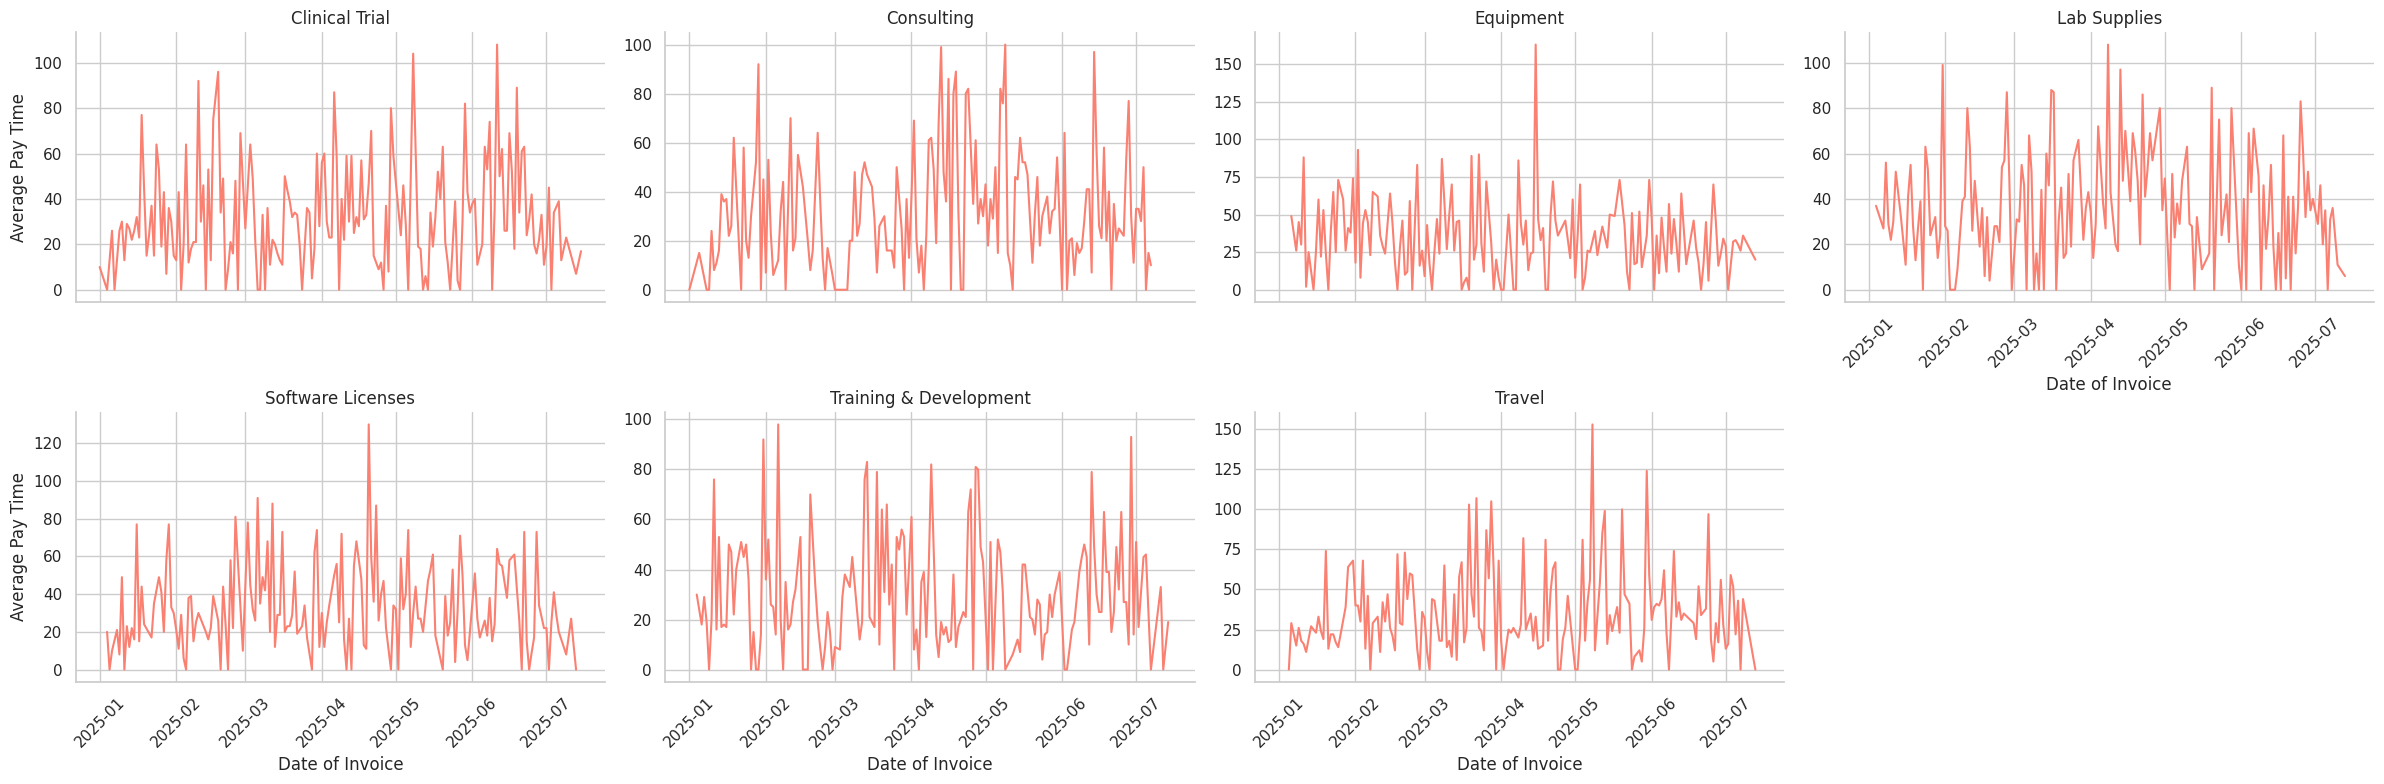

In [127]:
# Grouping by Category and Date to aggregate invoice values
plot_data = payment_merge.groupby(['Type of expense', 'Date of invoice'])['avg_pay_time'].sum().reset_index()

# Plotting
sns.set_style("whitegrid")
g = sns.FacetGrid(plot_data, col="Type of expense", col_wrap=4, height=4, aspect=1.5, sharey=False)
g.map(sns.lineplot, "Date of invoice", "avg_pay_time",color="salmon")

# Formatting
g.set_titles("{col_name}")
g.set_axis_labels("Date of Invoice", "Average Pay Time")

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

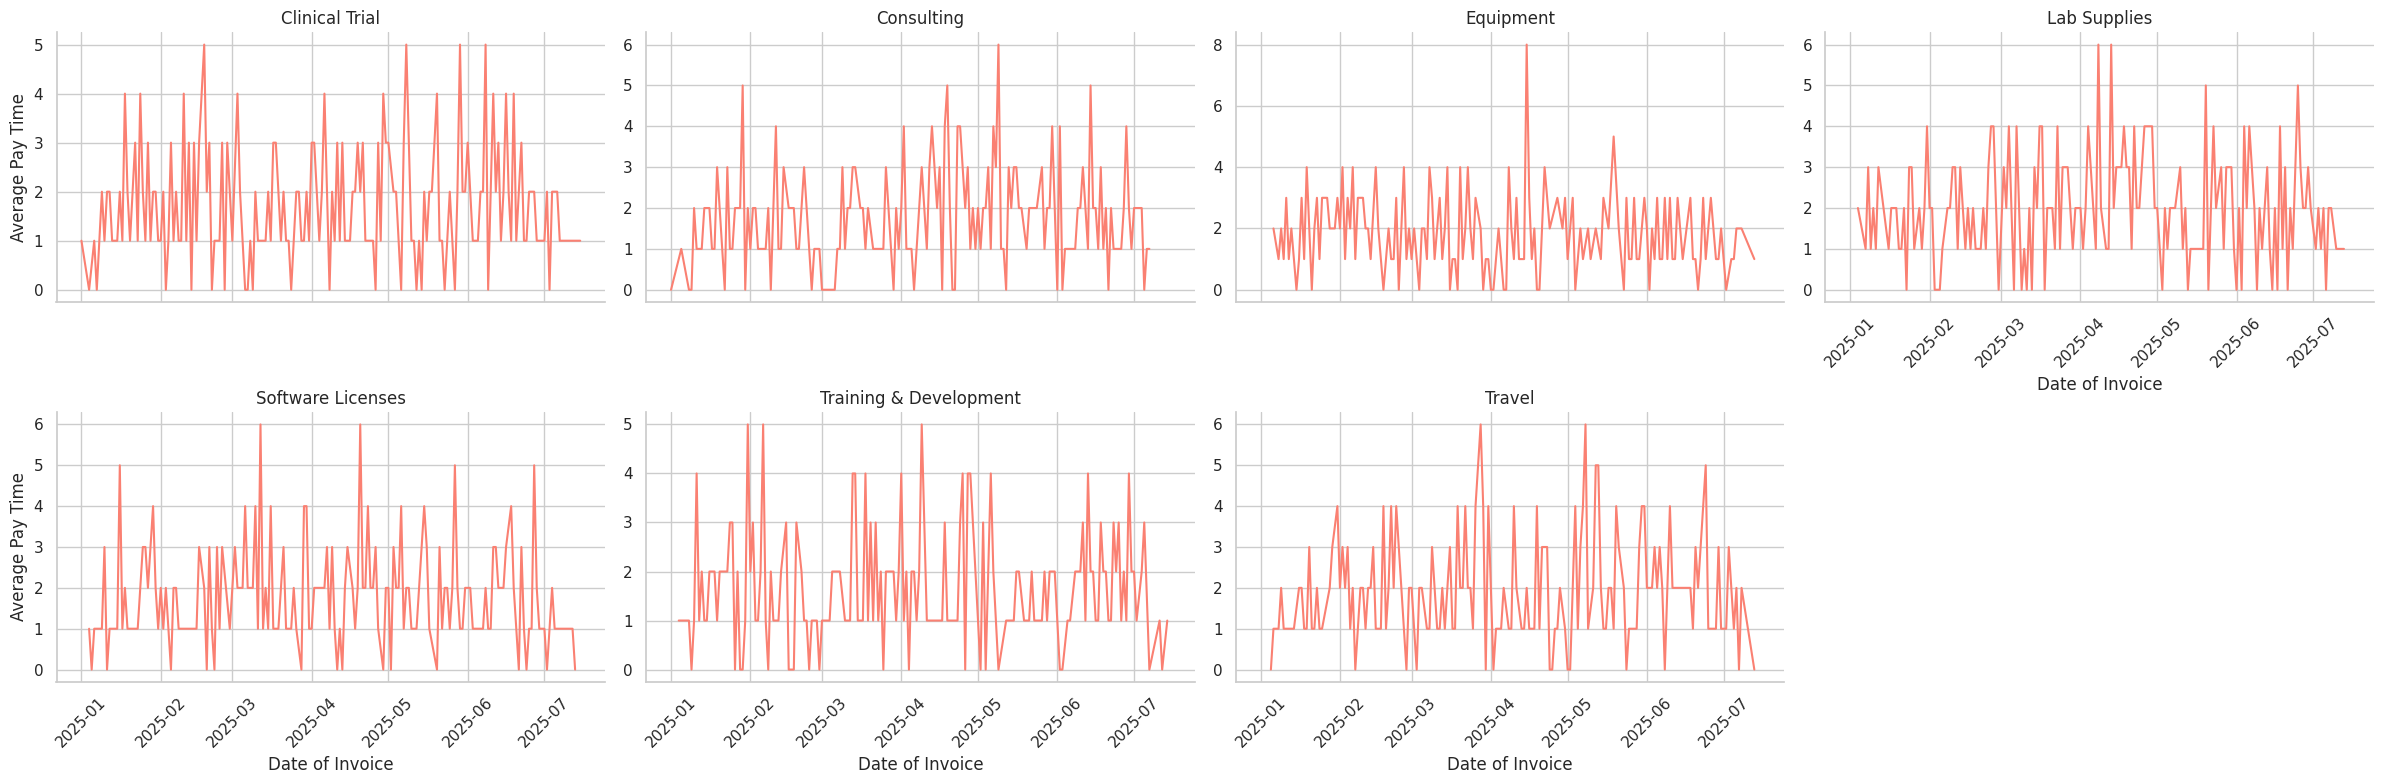

In [128]:
# Grouping by Category and Date to aggregate invoice values
plot_data = payment_merge.groupby(['Type of expense', 'Date of invoice'])['avg_pay_time'].count().reset_index()

# Plotting
sns.set_style("whitegrid")
g = sns.FacetGrid(plot_data, col="Type of expense", col_wrap=4, height=4, aspect=1.5, sharey=False)
g.map(sns.lineplot, "Date of invoice", "avg_pay_time",color="salmon")

# Formatting
g.set_titles("{col_name}")
g.set_axis_labels("Date of Invoice", "Average Pay Time")

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

#Average payment time by expense type, value and location;

#Comparing each team spend against their budget.

In [117]:
# Binning Invoice Value for categorical analysis
bins = [0, 4000, 8000, 12000, 16000, 20000]
labels = ['very low (<4k)','Low (<4k-8k)', 'Medium (8k-12k)', 'High (12k-16k)', 'Very High (>16k)']
payment_merge['Value Bin'] = pd.cut(payment_merge['Invoice value'], bins=bins, labels=labels)

# Average Payment Times
avg_pay_expense = payment_merge.groupby('Type of expense')['avg_pay_time'].mean().unstack()
avg_pay_location = payment_merge.groupby('Location')['avg_pay_time'].mean().sort_values()
avg_pay_value = payment_merge.groupby('Value Bin')['avg_pay_time'].mean()

/tmp/ipykernel_23580/3499539299.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_pay_value = payment_merge.groupby('Value Bin')['avg_pay_time'].mean()
/tmp/ipykernel_23580/3499539299.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  volume = payment_merge.groupby('Value Bin')['avg_pay_time'].count()


In [133]:
avg_pay_value

,avg_pay_time
Value Bin,
very low (<4k),18.33
Low (<4k-8k),18.51
Medium (8k-12k),18.27
High (12k-16k),18.97
Very High (>16k),18.38


#3. Outliers:

In [99]:
team_results = []
for team in payment_merge['Research team'].unique():
    team_subset = payment_merge[payment_merge['Research team'] == team].copy()

    # Z-score for Invoice value within the team
    iv_mean, iv_std = team_subset['Invoice value'].mean(), team_subset['Invoice value'].std()
    team_subset['zscore invoice'] = (team_subset['Invoice value'] - iv_mean) / iv_std

    # Z-score for avg_pay_time within the team
    pt_mean, pt_std = team_subset['avg_pay_time'].mean(), team_subset['avg_pay_time'].std()
    team_subset['zscore paytime'] = (team_subset['avg_pay_time'] - pt_mean) / pt_std

    team_results.append(team_subset)

df_team_z = pd.concat(team_results)

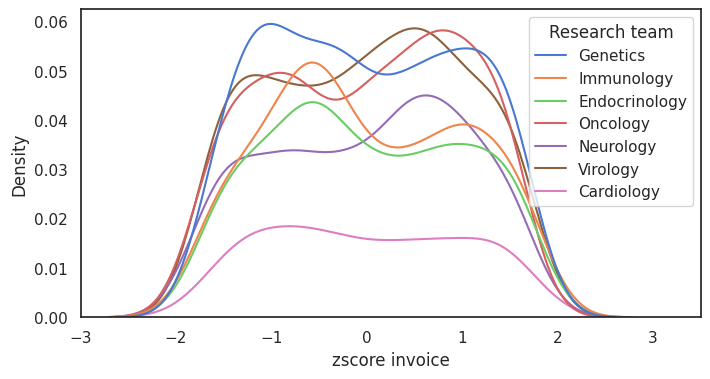

In [109]:
plt.figure(figsize=(8, 4))
ax= sns.kdeplot(data=df_team_z, x="zscore invoice", hue="Research team",palette="muted")
ax.set_xlim(-3, 3.5)
sns.move_legend(ax, loc="upper right")

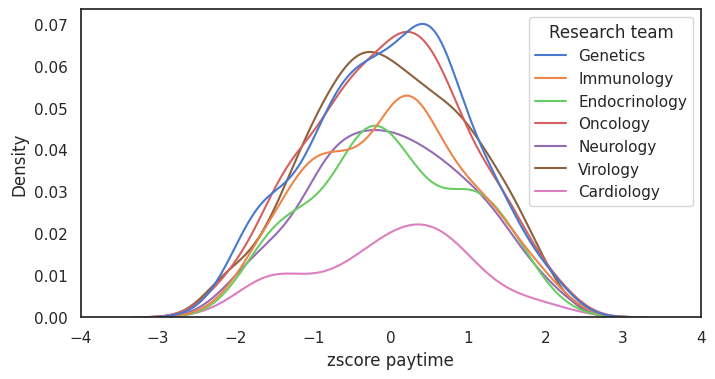

In [111]:
plt.figure(figsize=(8, 4))
ax= sns.kdeplot(data=df_team_z, x="zscore paytime", hue="Research team",palette="muted")
ax.set_xlim(-4, 4)
sns.move_legend(ax, loc="upper right")

Text(0.5, 1.05, 'Z-score Distribution: Avg Pay Time by Team')

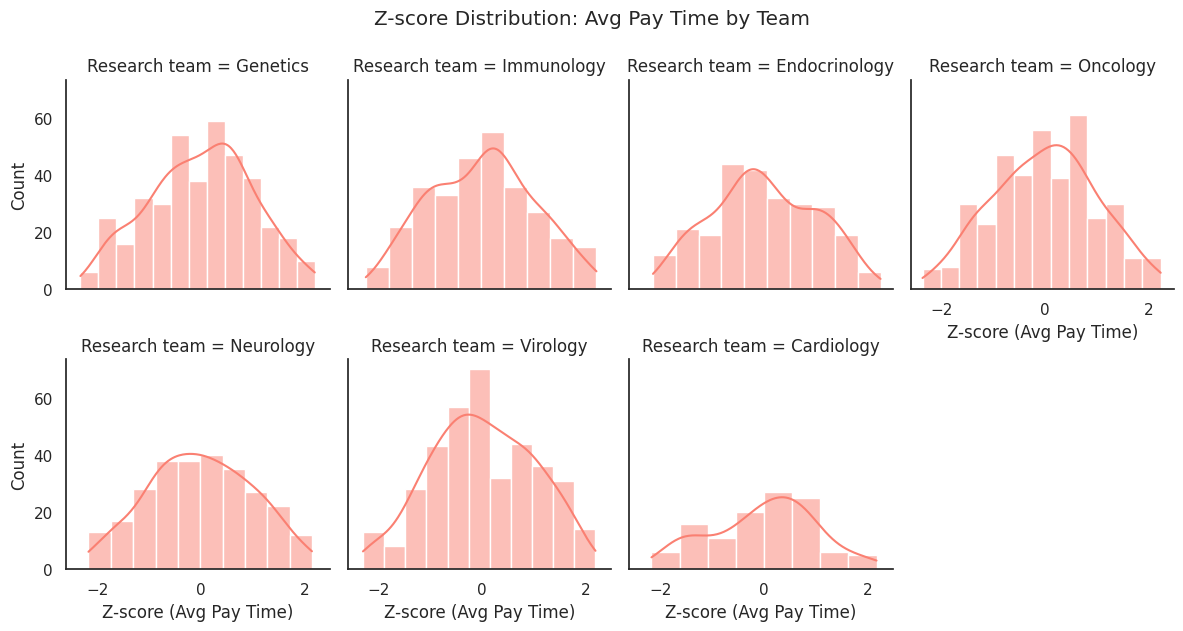

In [10]:
# Payment Time Z-scores
g2 = sns.FacetGrid(df_team_z, col="Research team", col_wrap=4, height=3, sharex=True)
g2.map(sns.histplot, "zscore_paytime_team", kde=True, color="salmon")
g2.set_axis_labels("Z-score (Avg Pay Time)", "Count")
g2.fig.suptitle('Z-score Distribution: Avg Pay Time by Team', y=1.05)

#2. What impacts the time taken to pay the invoice/ request:

Feature Creation:


---


1.   days_to_receive: wait time between invoice creation and receipt
2.   Payment authoriser role/designation

In [13]:
payment_merge['Date received'] = pd.to_datetime(payment_merge['Date received'])
payment_merge['Date of invoice'] = pd.to_datetime(payment_merge['Date of invoice'])
payment_merge['days_to_receive'] = (payment_merge['Date received'] - payment_merge['Date of invoice']).dt.days

In [12]:
# get location of payment
payment_merge=payment_merge.merge(members[members['Team']=='Payments'][['Name','Role']].drop_duplicates(), how='left', left_on='Payment authoriser', right_on='Name', suffixes=("","_authorizer")).drop(columns=['Name'])
payment_merge['Role_authorizer']=payment_merge['Role_authorizer'].fillna("Director")
payment_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date received          2956 non-null   datetime64[ns]
 1   Research team          2956 non-null   object        
 2   Submitted by           2956 non-null   object        
 3   Date of invoice        2956 non-null   object        
 4   Invoice number         2956 non-null   object        
 5   Description of spend   2956 non-null   object        
 6   Invoice value          2956 non-null   float64       
 7   Date of authorisation  2956 non-null   object        
 8   Authorised by          2956 non-null   object        
 9   Payment due date       2956 non-null   object        
 10  Date of payment        2096 non-null   datetime64[ns]
 11  Payment amount         2096 non-null   float64       
 12  Payment authoriser     2956 non-null   object        
 13  Pay

In [46]:
for i in ['Type of expense', 'Location', 'Role',"Role_authorizer"]:
  payment_merge[i+"_encoded"] = payment_merge[i].map(payment_merge.groupby(i)['avg_pay_time'].median().to_dict())

In [60]:
# Select predictors
features = ['Invoice value', 'days_to_receive', 'Annual budget',
       'Type of expense_encoded', 'Location_encoded', 'Role_encoded',
       'Role_authorizer_encoded']
X = payment_merge[features].fillna(0)
X.columns=['Invoice value', 'days_to_receive', 'Annual budget',
       'Type of expense', 'Location', 'Role','Role_authorizer']
y = payment_merge['avg_pay_time'].fillna(0)

In [61]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Invoice value    2956 non-null   float64
 1   days_to_receive  2956 non-null   int64  
 2   Annual budget    2956 non-null   float64
 3   Type of expense  2956 non-null   float64
 4   Location         2956 non-null   float64
 5   Role             2956 non-null   float64
 6   Role_authorizer  2956 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 161.8 KB


In [63]:
X_vif = sm.add_constant(X)

R-squared: 0.001
Adj R-squared: -0.001


Text(0.5, 1.0, 'Residuals vs Predicted Values')

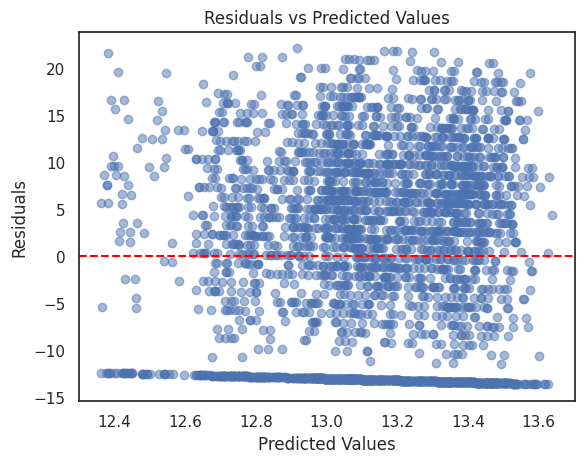

In [64]:
import matplotlib.pyplot as plt

model = sm.OLS(y, X_vif).fit()
print(f"R-squared: {model.rsquared:.3f}")
print(f"Adj R-squared: {model.rsquared_adj:.3f}")

# Residual Plot
y_pred = model.predict(X_vif)
residuals = y - y_pred

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')

In [65]:
beta_stats = pd.DataFrame({
    'Beta': model.params,
    'Std.Error': model.bse,
    't-stat': model.tvalues,
    'p-value': model.pvalues
})

# Concatenate confidence intervals (95% default)
beta_stats = pd.concat([beta_stats, model.conf_int()], axis=1)
beta_stats.rename(columns={0: 'Lower 95%', 1: 'Upper 95%'}, inplace=True)

# Filter for statistically significant variables (p < 0.05)
significant_vars = beta_stats[beta_stats['p-value'] < 0.05]

In [66]:
beta_stats[['Beta','p-value']].T

,Invoice value,days_to_receive,Annual budget,Type of expense,Location,Role,Role_authorizer
Beta,-0.00,0.01,0.00,0.26,0.35,-0.44,0.53
p-value,0.74,0.89,0.85,0.54,0.43,0.61,0.40


#SECTION 2: NLP

In [197]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

descriptions = payment_merge['Description of spend'].tolist()

# Load DistilBERT
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased")

def get_embed(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

# Generate vectors for all descriptions
X = [get_embed(doc) for doc in descriptions]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


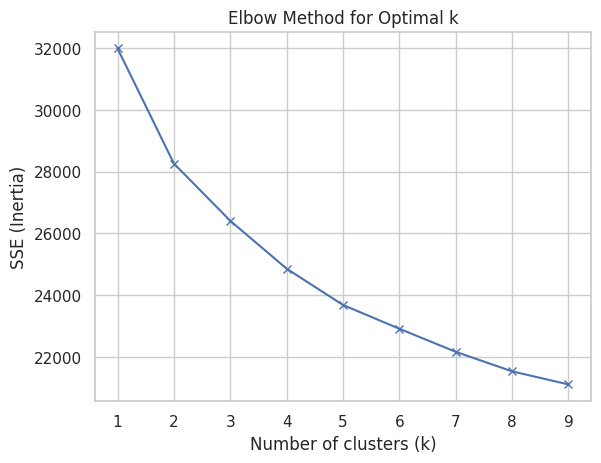

In [198]:
sse = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

# Plot Elbow
plt.plot(K, sse, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.show()

# Apply final clustering (k=4 based on the elbow)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
payment_merge['Cluster_Label'] = kmeans.fit_predict(X)

In [216]:
payment_merge[['Cluster_Label','Invoice value']].groupby('Cluster_Label').sum()

,Invoice value
Cluster_Label,
0,7141953.71
1,5504764.12
2,5637736.12
3,12211156.96


In [222]:
for i in range(4):
    print(f"--- Cluster {i} ---")

    cluster_text = payment_merge[payment_merge['Cluster_Label'] == i]['Description of spend'].str.lower()

    vec_bi = CountVectorizer(stop_words=custom_stopwords, ngram_range=(2,2), max_features=3)
    bow_bi = vec_bi.fit_transform(cluster_text)
    sum_words_bi = bow_bi.sum(axis=0)
    words_freq_bi = [(word, sum_words_bi[0, idx]) for word, idx in vec_bi.vocabulary_.items()]
    words_freq_bi = pd.DataFrame(sorted(words_freq_bi, key = lambda x: x[1], reverse=True),columns=['Words', 'Frequency'])
    display(list(words_freq_bi['Words']))

--- Cluster 0 ---


['elisa kits', 'quantify cytokine', 'cancer immunotherapy']

--- Cluster 1 ---


['personal protective', 'protective equipment', 'equipment ppe']

--- Cluster 2 ---


['software licenses', 'databases literature', 'variant interpretation']

--- Cluster 3 ---


['immune cell', 'extraction kits', 'gene expression']

In [178]:
feedback=pd.read_csv('https://raw.githubusercontent.com/shin-jini/BUPA_Case_Study/main/Payement_Information/Customer_Feedback_Master.csv')

#Rating Analysis
print(feedback['Rating'].value_counts(normalize=True))

# Monthly Trend Analysis for negative ratings
feedback['Date'] = pd.to_datetime(feedback['Date'], format='%d/%m/%Y')
feedback['month_year'] = feedback['Date'].dt.to_period('M')
feedback["rating_negative"]=np.where(feedback['Rating']<=2,1,0)
trend = feedback[['rating_negative','month_year']].groupby('month_year').mean()

Rating
5   0.62
1   0.18
4   0.08
2   0.07
3   0.05
Name: proportion, dtype: float64


/tmp/ipykernel_23580/2718056061.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_df.head(15), x='Frequency', y='Word', palette='crest')


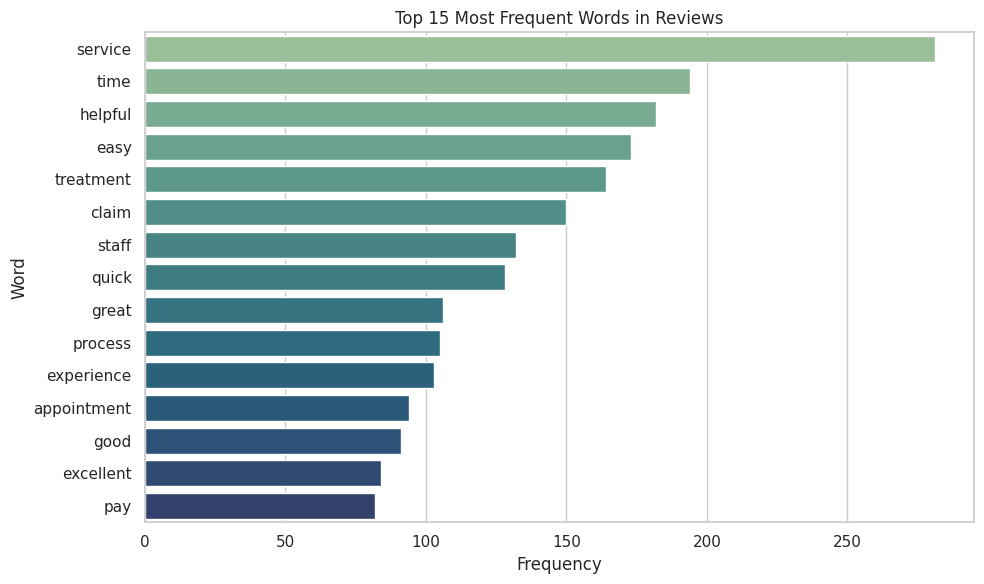

In [155]:
import re
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Drop missing reviews
feedback = feedback.dropna(subset=['Review'])

# Text Cleaning
stop_words = set(stopwords.words('english'))
# useless words in this context
custom_stopwords = list(stop_words) + ['abc', 'healthcare','get','phone','call','would','customer','years','really']

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

feedback['Clean_Review'] = feedback['Review'].apply(clean_text)

# Top Words
vec = CountVectorizer(stop_words=custom_stopwords, max_features=20)
bow = vec.fit_transform(feedback['Clean_Review'])
sum_words = bow.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)

words_df = pd.DataFrame(words_freq, columns=['Word', 'Frequency'])

# Plot Top Words
plt.figure(figsize=(10, 6))
sns.barplot(data=words_df.head(15), x='Frequency', y='Word', palette='crest')
plt.title('Top 15 Most Frequent Words in Reviews')
plt.tight_layout()

/tmp/ipykernel_23580/3551243408.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_df.head(15), x='Frequency', y='Word', palette='crest')


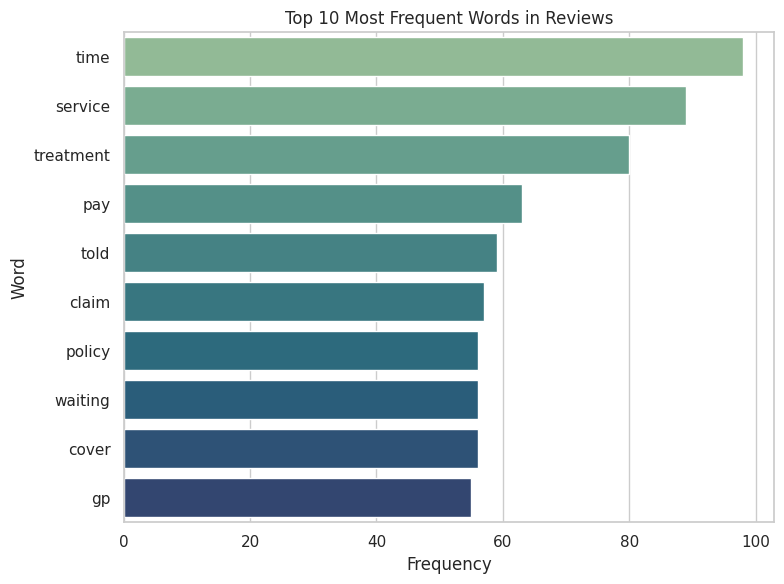

In [158]:
# Top Words
vec = CountVectorizer(stop_words=custom_stopwords, max_features=10)
bow = vec.fit_transform(feedback[feedback['Rating']<=2]['Clean_Review'])
sum_words = bow.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)

words_df = pd.DataFrame(words_freq, columns=['Word', 'Frequency'])

# Plot Top Words
plt.figure(figsize=(8, 6))
sns.barplot(data=words_df.head(15), x='Frequency', y='Word', palette='crest')
plt.title('Top 10 Most Frequent Words in Reviews')
plt.tight_layout()

/tmp/ipykernel_23580/1379976108.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_freq_bi.head(10), x='Frequency', y='Words', palette='crest')


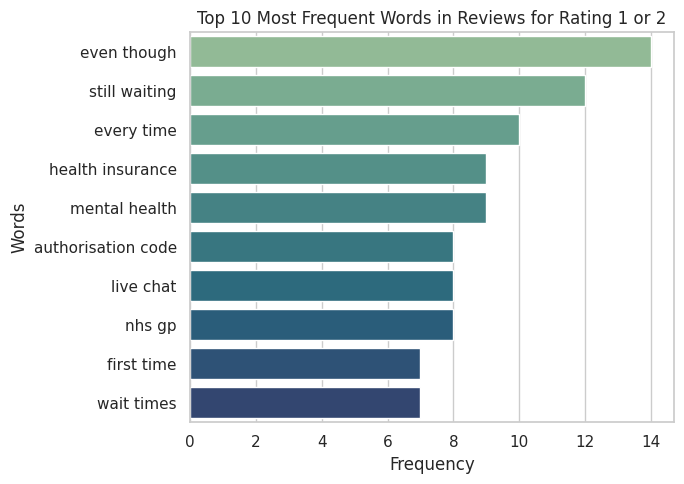

In [167]:
vec_bi = CountVectorizer(stop_words=custom_stopwords, ngram_range=(2,2), max_features=10)
bow_bi = vec_bi.fit_transform(feedback[feedback['Rating']<=2]['Clean_Review'])
sum_words_bi = bow_bi.sum(axis=0)
words_freq_bi = [(word, sum_words_bi[0, idx]) for word, idx in vec_bi.vocabulary_.items()]
words_freq_bi = pd.DataFrame(sorted(words_freq_bi, key = lambda x: x[1], reverse=True),columns=['Words', 'Frequency'])

# Plot Top Words
plt.figure(figsize=(7, 5))
sns.barplot(data=words_freq_bi.head(10), x='Frequency', y='Words', palette='crest')
plt.title('Top 10 Most Frequent Words in Reviews for Rating 1 or 2')
plt.tight_layout()

In [190]:
df=pd.DataFrame(feedback['Review'].str.len())
df[df['Review']>512]

,Review
0,674
1,1295
11,786
13,532
18,963
...,...
921,1365
923,597
925,674
928,600


In [192]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

results = classifier(feedback['Review'].tolist(), truncation=True, batch_size=32)

feedback['Sentiment'] = [res['label'] for res in results]
feedback['Confidence'] = [res['score'] for res in results]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [194]:
feedback['Sentiment'].value_counts(normalize=1)

,proportion
Sentiment,
POSITIVE,0.63
NEGATIVE,0.37
